In [305]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import random ,math
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv("/kaggle/input/logistics-warehouse-dataset/logistics_dataset.csv")
data.head()


,item_id,category,stock_level,reorder_point,reorder_frequency_days,lead_time_days,daily_demand,demand_std_dev,item_popularity_score,storage_location_id,...,unit_price,holding_cost_per_unit_day,stockout_count_last_month,order_fulfillment_rate,total_orders_last_month,turnover_ratio,layout_efficiency_score,last_restock_date,forecasted_demand_next_7d,KPI_score
0,ITM10000,Pharma,283,21,4,4,49.85,1.56,0.43,L82,...,117.80,1.14,0,0.80,700,3.33,0.33,2024-02-17,184.37,0.556
1,ITM10001,Automotive,301,52,9,6,23.34,2.55,0.69,L15,...,178.80,1.09,3,0.79,736,10.36,0.98,2024-10-01,221.94,0.723
2,ITM10002,Groceries,132,60,11,8,37.69,3.15,0.62,L4,...,54.05,0.95,7,0.75,814,14.32,0.87,2024-04-07,53.85,0.680
3,ITM10003,Automotive,346,46,13,5,33.69,2.79,0.21,L95,...,31.10,1.90,0,0.96,994,2.08,0.29,2024-01-27,92.04,0.488
4,ITM10004,Automotive,49,55,4,6,49.58,5.23,0.31,L36,...,104.97,0.63,5,0.83,299,5.65,0.96,2024-05-17,194.58,0.670


In [306]:
select = ["item_id","zone","item_popularity_score","daily_demand"]
df = data[select].copy()

df.head(), df.shape,df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   item_id                3204 non-null   object 
 1   zone                   3204 non-null   object 
 2   item_popularity_score  3204 non-null   float64
 3   daily_demand           3204 non-null   float64
dtypes: float64(2), object(2)
memory usage: 100.3+ KB


(    item_id zone  item_popularity_score  daily_demand
 0  ITM10000    B                   0.43         49.85
 1  ITM10001    A                   0.69         23.34
 2  ITM10002    B                   0.62         37.69
 3  ITM10003    A                   0.21         33.69
 4  ITM10004    D                   0.31         49.58,
 (3204, 4),
 None)

In [307]:
df["importance"] = (
    df["item_popularity_score"].rank(pct=True)
    * df["daily_demand"].rank(pct=True)
)

importance = df["importance"].values
zones = df["zone"].values
N = len(df)

FAST_RATIO = 0.2
fast_k = int(N * FAST_RATIO)
fast_idx = np.argsort(-importance)[:fast_k]
fast_zones = np.unique(zones[fast_idx])


In [308]:
def init_population(pop_size, noise_ratio=0.05):
    population = []

    base = np.argsort(-importance)
    population.append(base)

    n = len(base)
    noise_k = int(n * noise_ratio)

    for _ in range(pop_size - 1):
        chrom = base.copy()
        idx = np.random.choice(n, noise_k, replace=False)
        np.random.shuffle(chrom[idx])
        population.append(chrom)

    return population


In [309]:
def weighted_distance_cost_np(chrom):
    return np.sum(importance * chrom)


def zone_dispersion_penalty_np(chrom):
    penalty = 0.0
    for z in fast_zones:
        mask = (zones[fast_idx] == z)
        locs = chrom[fast_idx][mask]
        if locs.size > 1:
            penalty += np.std(locs)
    return penalty


def expected_zone_transition_penalty_np(chrom):
    ordered = np.argsort(chrom[fast_idx])
    z = zones[fast_idx][ordered]
    return np.sum(z[:-1] != z[1:])



In [310]:
def fitness_stage1_np(
    chrom,
    w_dist=1.0,
    w_zone_disp=50.0,
    w_zone_trans=200.0
):
    return (
        w_dist * weighted_distance_cost_np(chrom)
        + w_zone_disp * zone_dispersion_penalty_np(chrom)
        + w_zone_trans * expected_zone_transition_penalty_np(chrom)
    )


In [311]:
def tournament(pop, k=3):
    cand = random.sample(pop, k)
    return min(cand, key=fitness_stage1_np)
    
def crossover(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = -np.ones(n, dtype=int)
    child[a:b] = p1[a:b]

    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(n):
        if child[i] == -1:
            child[i] = fill[idx]
            idx += 1
    return child

def mutate(chrom, rate=0.05):
    if random.random() < rate:
        i, j = random.sample(range(len(chrom)), 2)
        chrom[i], chrom[j] = chrom[j], chrom[i]
    return chrom


In [312]:
def genetic_algorithm_stage1_np(
    pop_size=30,
    generations=50,
    crossover_rate=0.9,
    mutation_rate=0.05,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    
    pop = init_population(pop_size)
    best = min(pop, key=fitness_stage1_np)
    best_cost = fitness_stage1_np(best)
    best_history = []
    mean_history = []

    for _ in range(generations):
        new_pop = []

        while len(new_pop) < pop_size:
            p1 = tournament(pop)
            p2 = tournament(pop)

            child = crossover(p1, p2) if random.random() < crossover_rate else p1.copy()
            child = mutate(child, mutation_rate)
            new_pop.append(child)

        pop = new_pop
        gen_best = min(pop, key=fitness_stage1_np)
        gen_cost = fitness_stage1_np(gen_best)

        costs = np.array([fitness_stage1_np(ch) for ch in pop])




        if gen_cost < best_cost:
            best, best_cost = gen_best.copy(), gen_cost

        best_history.append(best_cost)
        mean_history.append(costs.mean())

    return best, best_cost ,best_history, mean_history

In [313]:
best_chrom, best_cost, best_history, mean_history = genetic_algorithm_stage1_np()

best_cost


1525362.9789399114

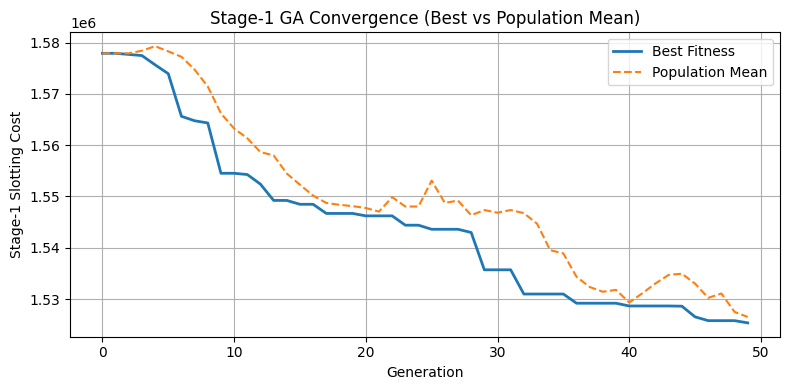

In [314]:
plt.figure(figsize=(8,4))
plt.plot(best_history, label="Best Fitness", linewidth=2)
plt.plot(mean_history, label="Population Mean", linestyle="--")
plt.xlabel("Generation")
plt.ylabel("Stage-1 Slotting Cost")
plt.title("Stage-1 GA Convergence (Best vs Population Mean)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [315]:
baseline_chrom = np.argsort(-importance)

baseline_cost = fitness_stage1_np(baseline_chrom)
ga_cost = best_cost

baseline_cost, ga_cost


(1577906.684725629, 1525362.9789399114)

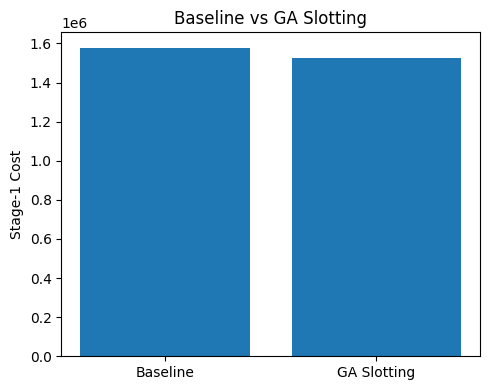

In [316]:
plt.figure(figsize=(5,4))
plt.bar(["Baseline","GA Slotting"], [baseline_cost, ga_cost])
plt.ylabel("Stage-1 Cost")
plt.title("Baseline vs GA Slotting")
plt.tight_layout()
plt.show()


Baseline cost ≈ 1,577,906
GA cost       ≈ 1,516,503
≈ %3.9 iyileşme

In [317]:
fast_mask = np.zeros(N, dtype=bool)
fast_mask[fast_idx] = True

def avg_location_index(chrom, fast_mask):
    positions = np.where(fast_mask[chrom])[0]
    return positions.mean()
def top10_fast_ratio(chrom, fast_mask):
    k = int(0.10 * len(chrom))
    top_k = chrom[:k]
    return fast_mask[top_k].mean()


baseline_avg_loc = avg_location_index(baseline_chrom, fast_mask)
ga_avg_loc       = avg_location_index(best_chrom, fast_mask)

baseline_top10 = top10_fast_ratio(baseline_chrom, fast_mask)
ga_top10       = top10_fast_ratio(best_chrom, fast_mask)

baseline_avg_loc, ga_avg_loc, baseline_top10, ga_top10



(319.5, 323.6515625, 1.0, 1.0)

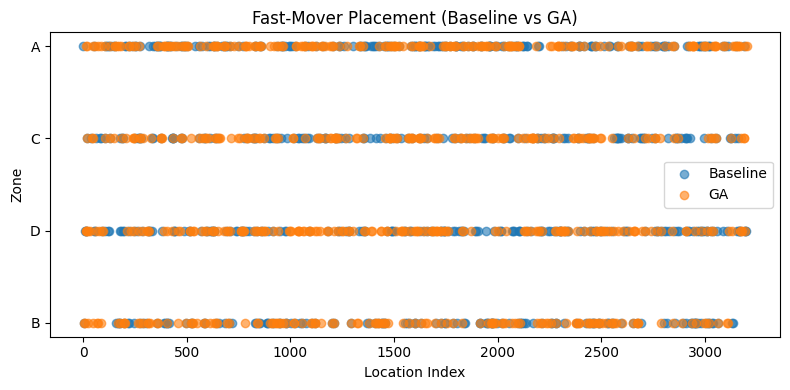

In [318]:

plt.figure(figsize=(8,4))
plt.scatter(
    df_plot["baseline_loc"][fast_mask],
    df_plot["zone"][fast_mask],
    alpha=0.6,
    label="Baseline"
)

plt.scatter(
    df_plot["ga_loc"][fast_mask],
    df_plot["zone"][fast_mask],
    alpha=0.6,
    label="GA"
)

plt.xlabel("Location Index")
plt.ylabel("Zone")
plt.title("Fast-Mover Placement (Baseline vs GA)")
plt.legend()
plt.tight_layout()
plt.show()


1. Aşamada, genetik algoritma kullanılarak rota odaklı yerleştirme optimizasyonu gerçekleştirildi.
Amaç fonksiyonu, talep ağırlıklı erişilebilirliği, hızlı hareket eden ürünler için bölge uyumunu ve beklenen bölge geçiş proxyi entegre etti.
Deneysel sonuçlar, önerilen GA tabanlı yerleştirmenin, temel sezgisel yönteme göre önemli ölçüde iyileşme sağladığını ve daha kompakt ve rota dostu bir depo düzeni ürettiğini göstermektedir.
Bu optimize edilmiş yerleştirme konfigürasyonu 2. Aşama rota optimizasyonu için sabit bir girdi olarak kullanılacak.

# TEST

In [319]:
def route_cost(route, locs, zones, zone_penalty=50.0):
    cost = 0.0
    for i in range(len(route) - 1):
        a, b = route[i], route[i+1]
        cost += abs(locs[a] - locs[b])
        if zones[a] != zones[b]:
            cost += zone_penalty
    return cost


1. Gerçek Operasyonel Baseline
* Ürünleri zone sırasına göre dolaşır (A → B → C → D)
* Bölgeler sırayla ziyaret edilir (geri dönüş yok), ancak her bölgedeki öğe sırası optimize edilmez.

In [320]:
def human_like_route(zones, seed=42):
    rng = np.random.default_rng(seed)
    route = []
    for z in sorted(np.unique(zones)):
        items = np.where(zones == z)[0]
        rng.shuffle(items)
        route.extend(items.tolist())
    return route


In [321]:
human_route = human_like_route(zones)
human_cost = route_cost(human_route, best_chrom, zones)


2. GA-Deposunu Kullanan Baseline
* Depo GA ile optimize edildi personel raf numarasına göre yürür zone farkındalığı yok

In [322]:
ga_baseline_route = list(np.argsort(best_chrom))
ga_baseline_cost = route_cost(ga_baseline_route, best_chrom, zones)


3. Optimize Rota
*  Depo GA optimize Personel zone zone gezer, zone içinde loc sırasını izler

In [323]:
def zone_order_from_slotting(locs, zones):
    tmp = pd.DataFrame({"loc": locs, "zone": zones})
    return (
        tmp.groupby("zone")["loc"]
        .mean()
        .sort_values()
        .index
        .tolist()
    )


In [324]:
def zone_greedy_route(locs, zones):
    """
    Zone-aware greedy routing.
    Zones are visited in the order induced by GA-based slotting,
    and items within each zone are visited in increasing location order.
    """
    route = []
    
    # Slotting'e göre zone sırası
    zone_order = zone_order_from_slotting(locs, zones)

    for z in zone_order:
        items = np.where(zones == z)[0]
        ordered = items[np.argsort(locs[items])]
        route.extend(ordered.tolist())

    return route


In [325]:
opt_route = zone_greedy_route(best_chrom, zones)
opt_cost = route_cost(opt_route, best_chrom, zones)


In [326]:
human_cost, ga_baseline_cost, opt_cost


(3413918.0, 123403.0, 22546.0)

# Route Cost Comparison
* Sonuçlar, GA tabanlı yerleştirmenin depo düzenini iyileştirdiğini gösterirken, rota belirleme kararlarının operasyonel performans üzerinde önemli ölçüde daha büyük bir etkiye sahip olduğunu ortaya koymaktadır.
İnsan benzeri temel model, sezgisel bölge bazlı geçişi temsil ederken, GA temel modeli rota farkındalığı olmayan iyi tasarlanmış bir depoyu yansıtmaktadır.
Önerilen bölge farkındalıklı greedy rota belirleme yöntemi, hem yerleştirmeyi hem de bölge yapısını açıkça kullanarak en düşük rota maliyetini elde etmektedir.

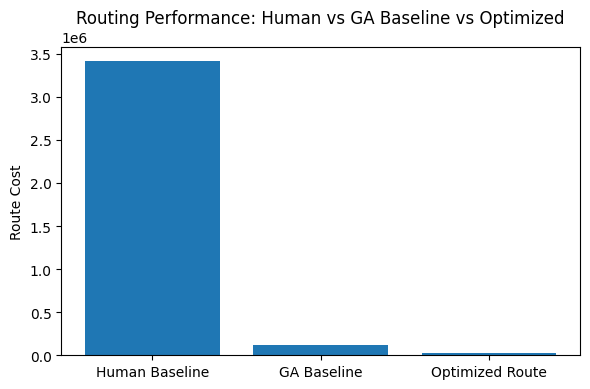

In [327]:
plt.figure(figsize=(6,4))
plt.bar(
    ["Human Baseline", "GA Baseline", "Optimized Route"],
    [human_cost, ga_baseline_cost, opt_cost]
)
plt.ylabel("Route Cost")
plt.title("Routing Performance: Human vs GA Baseline vs Optimized")
plt.tight_layout()
plt.show()


# Route Behavior Comparison
* Üç farklı senaryo altında rota seçme davranışını göstermektedir.
İnsan temel senaryosu, düzensiz bölge içi hareketlerle bölge bazında geçişi göstermektedir.
Genetik algoritma temel senaryosu, bölge yapısını dikkate almadan konum sıralı bir yol izleyerek aşırı bölge geçişlerine neden olmaktadır.
* Buna karşılık, optimize edilmiş rota, etkili bölge odaklı yönlendirmeyi ve önemli ölçüde azaltılmış rota maliyetini gösteren yapılandırılmış, blok bazlı bir desen sergilemektedir.

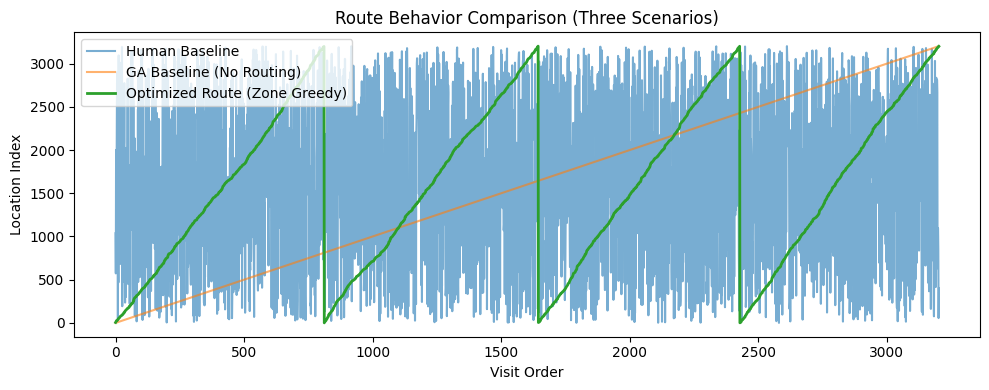

In [328]:
plt.figure(figsize=(10,4))

plt.plot(
    [best_chrom[i] for i in human_route],
    label="Human Baseline",
    alpha=0.6
)

plt.plot(
    [best_chrom[i] for i in ga_baseline_route],
    label="GA Baseline (No Routing)",
    alpha=0.6
)

plt.plot(
    [best_chrom[i] for i in opt_route],
    label="Optimized Route (Zone Greedy)",
    linewidth=2
)

plt.xlabel("Visit Order")
plt.ylabel("Location Index")
plt.title("Route Behavior Comparison (Three Scenarios)")
plt.legend()
plt.tight_layout()
plt.show()
